# Bloque 1. Generación de datos sintéticos para la dinámica de la bomba en el sistema ORC

En este primer bloque se construye la base del experimento numérico que posteriormente será utilizada para entrenar la red neuronal informada por física (PINN). El propósito principal es generar datos sintéticos controlados a partir de la ecuación diferencial que modela la respuesta dinámica de la bomba dentro del sistema ORC. De esta forma, antes de entrenar la red, se dispone de una solución de referencia físicamente consistente, que servirá como verdad de terreno (*ground truth*) para evaluar la capacidad de reconstrucción del modelo.

La bomba se modela como un sistema dinámico de primer orden, donde el flujo másico real no cambia instantáneamente ante una consigna impuesta, sino que evoluciona de manera gradual con una velocidad determinada por su constante de tiempo mecánica. Esta dinámica se representa mediante la siguiente ecuación diferencial ordinaria:

$$
\tau_{pump}\frac{dm(t)}{dt} = m_{target}(t) - m(t)
$$

donde:

- $m(t)$ es el flujo másico real de la bomba,
- $m_{target}(t)$ es la señal de consigna o flujo másico deseado,
- $\tau_{pump}$ es la constante de tiempo de la bomba.

Desde el punto de vista físico, esta ecuación indica que la bomba intenta seguir la señal objetivo $m_{target}(t)$, pero lo hace con una respuesta progresiva debido a la inercia propia del sistema. Por esta razón, el flujo real $m(t)$ no coincide de inmediato con la entrada, sino que presenta un transitorio cuya duración depende de $\tau_{pump}$.

Para analizar distintos comportamientos dinámicos, en este bloque se definen varias entradas prototipo para la señal $m_{target}(t)$: una entrada tipo escalón, una entrada cosenoidal, una rampa y un pulso rectangular. Cada una de estas señales permite excitar el sistema de manera diferente y observar cómo responde la bomba frente a cambios bruscos, variaciones suaves, incrementos progresivos o activaciones temporales.

A continuación, la ecuación diferencial se reescribe en su forma explícita de primer orden para ser resuelta numéricamente:

$$
\frac{dm(t)}{dt} = \frac{m_{target}(t) - m(t)}{\tau_{pump}}
$$

Con esta formulación, se utiliza la función `solve_ivp` de SciPy para obtener la solución temporal del sistema en un intervalo definido. El resultado de esta simulación es una trayectoria sintética de $m(t)$ para cada caso de entrada, junto con la señal de consigna correspondiente.

Finalmente, los resultados se organizan en estructuras tabulares (`DataFrame`) que almacenan, para cada caso, el tiempo, el flujo másico real, la señal objetivo y el parámetro de la bomba. Estos datos constituyen la base sobre la cual, en los siguientes bloques, se generarán observaciones con ruido y se entrenará la PINN.

En resumen, este bloque no entrena todavía la red neuronal; su función es construir un conjunto de datos sintéticos físicamente coherente que permita estudiar, en un entorno controlado, cómo una PINN puede aprender la dinámica de la bomba a partir de la ecuación gobernante y de observaciones parciales.

Casos disponibles: ['ESCALON' 'COSENO' 'RAMPA' 'PULSO']


,caso,t,m,m_target,tau_pump
0,ESCALON,0.000000,0.0,0.0,5.0
1,ESCALON,0.050025,0.0,0.0,5.0
2,ESCALON,0.100050,0.0,0.0,5.0
3,ESCALON,0.150075,0.0,0.0,5.0
4,ESCALON,0.200100,0.0,0.0,5.0


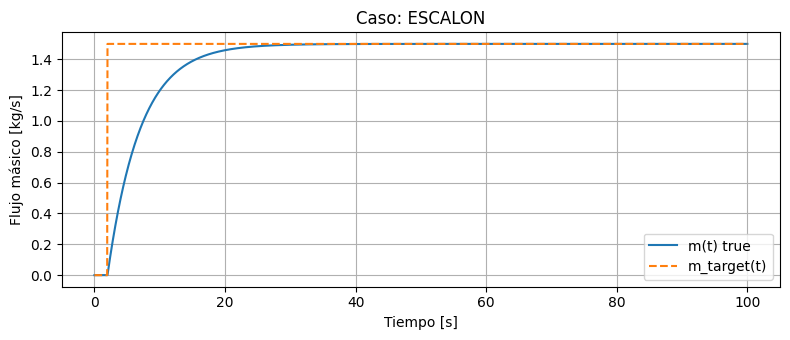

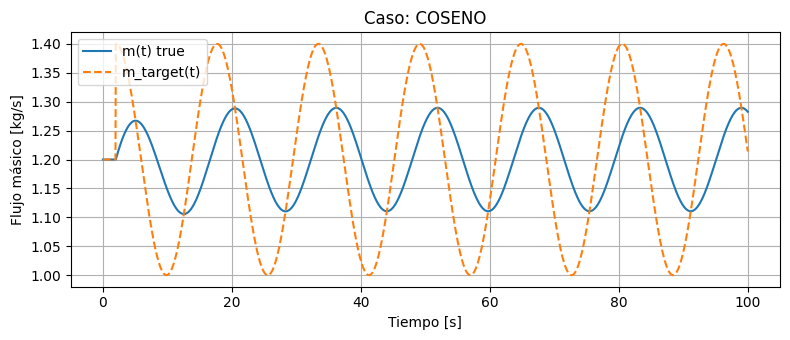

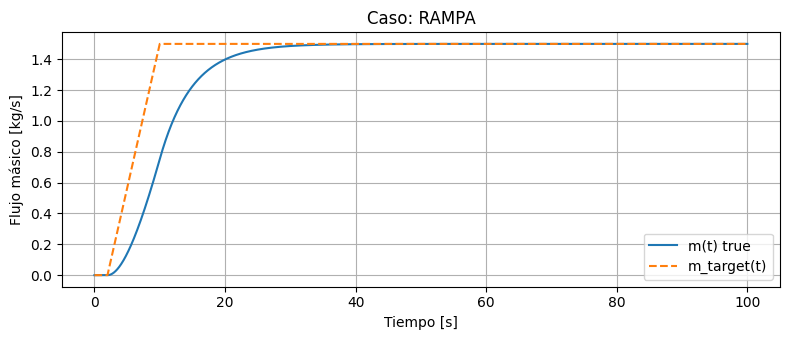

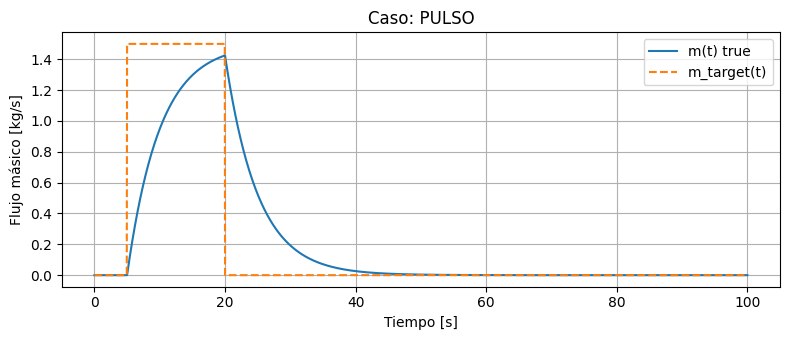

In [1]:
# ============================================================
# [BLOQUE 1] GENERACIÓN DE DATOS SINTÉTICOS — BOMBA ORC
# EDO:
#   tau_pump * dm(t)/dt = m_target(t) - m(t)
#
# Salida que usaremos en la PINN: m(t)
# Entrada: m_target(t) (escalón o señal suave)
# ============================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -----------------------------
# Parámetros del sistema
# -----------------------------
tau_pump = 5.0   # s  (constante de tiempo mecánica)

# -----------------------------
# Entradas m_target(t)
# -----------------------------
def mtarget_escalon(t, A=1.5, t0=2.0, **kwargs):
    return A if t >= t0 else 0.0

def mtarget_coseno(t, A=1.0, bias=1.2, w=0.5, t0=2.0, **kwargs):
    # antes de t0 mantenemos un valor base
    return bias if t < t0 else bias + A * np.cos(w * (t - t0))

def mtarget_rampa(t, m_ini=0.0, m_fin=1.5, t0=2.0, duracion=8.0, **kwargs):
    if t < t0:
        return m_ini
    elif t < t0 + duracion:
        s = (m_fin - m_ini) / duracion
        return m_ini + s * (t - t0)
    else:
        return m_fin

def mtarget_pulso(t, m_base=0.0, m_alto=1.5, t1=5.0, t2=20.0, **kwargs):
    return m_alto if (t1 <= t < t2) else m_base

# -----------------------------
# Dinámica de la bomba
# -----------------------------
def bomba_1er_orden(t, X, mtarget_fun, mtarget_kwargs, tau_pump):
    m = X[0]
    m_target_t = mtarget_fun(t, **mtarget_kwargs)
    dm_dt = (m_target_t - m) / tau_pump
    return [dm_dt]

# -----------------------------
# Generador de datos sintéticos
# -----------------------------
def generar_datos_bomba(
    nombre="BOMBA_ESCALON",
    mtarget_fun=mtarget_escalon,
    mtarget_kwargs=None,
    t_inicio=0.0,
    t_final=100.0,
    n_puntos=2000,
    m0=0.0,
    sigma_ruido_m=0.0,
    seed=123,
    tau_pump=tau_pump
):
    if mtarget_kwargs is None:
        mtarget_kwargs = {}

    t_eval = np.linspace(t_inicio, t_final, n_puntos)

    sol = solve_ivp(
        fun=lambda t, X: bomba_1er_orden(t, X, mtarget_fun, mtarget_kwargs, tau_pump),
        t_span=(t_inicio, t_final),
        y0=[m0],
        t_eval=t_eval,
        method="RK45",
        rtol=1e-9,
        atol=1e-11
    )

    t = sol.t
    m = sol.y[0]
    m_target = np.array([mtarget_fun(ti, **mtarget_kwargs) for ti in t])

    if sigma_ruido_m > 0:
        rng = np.random.default_rng(seed)
        m = m + rng.normal(0.0, sigma_ruido_m, size=m.shape)

    df = pd.DataFrame({
        "caso": nombre,
        "t": t,
        "m": m,
        "m_target": m_target,
        "tau_pump": tau_pump
    })
    return df

# -----------------------------
# Casos de ejemplo
# -----------------------------
df_bomba_escalon = generar_datos_bomba(
    nombre="ESCALON",
    mtarget_fun=mtarget_escalon,
    mtarget_kwargs={"A": 1.5, "t0": 2.0},
    m0=0.0,
    sigma_ruido_m=0.0,
    tau_pump=5.0
)

df_bomba_coseno = generar_datos_bomba(
    nombre="COSENO",
    mtarget_fun=mtarget_coseno,
    mtarget_kwargs={"A": 0.2, "bias": 1.2, "w": 0.4, "t0": 2.0},
    m0=1.2,
    sigma_ruido_m=0.0,
    tau_pump=5.0
)
df_bomba_rampa = generar_datos_bomba(
    nombre="RAMPA",
    mtarget_fun=mtarget_rampa,
    mtarget_kwargs={"m_ini": 0.0, "m_fin": 1.5, "t0": 2.0, "duracion": 8.0},
    m0=0.0,
    sigma_ruido_m=0.0,
    tau_pump=5.0
)

df_bomba_pulso = generar_datos_bomba(
    nombre="PULSO",
    mtarget_fun=mtarget_pulso,
    mtarget_kwargs={"m_base": 0.0, "m_alto": 1.5, "t1": 5.0, "t2": 20.0},
    m0=0.0,
    sigma_ruido_m=0.0,
    tau_pump=5.0
)

df_todos_bomba = pd.concat(
    [df_bomba_escalon, df_bomba_coseno, df_bomba_rampa, df_bomba_pulso],
    ignore_index=True
)

print("Casos disponibles:", df_todos_bomba["caso"].unique())
display(df_todos_bomba.head())

# Visualización rápida
for caso in df_todos_bomba["caso"].unique():
    d = df_todos_bomba[df_todos_bomba["caso"] == caso]
    plt.figure(figsize=(8, 3.5))
    plt.plot(d["t"], d["m"], label="m(t) true")
    plt.plot(d["t"], d["m_target"], "--", label="m_target(t)")
    plt.title(f"Caso: {caso}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Flujo másico [kg/s]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [2]:
!pip -q install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.1 MB/s eta 0:00:00


# Bloque 2. Implementación de la PINN para la dinámica de la bomba ORC

En este bloque se construye, entrena y evalúa una red neuronal informada por física (PINN) para aproximar la dinámica temporal del flujo másico de la bomba en el sistema ORC. A diferencia del bloque anterior, donde únicamente se generaron datos sintéticos a partir de la ecuación diferencial, aquí se utiliza esa información para entrenar una red neuronal que sea capaz de reconstruir la solución del sistema combinando tres fuentes de información: la física del problema, la condición inicial y un conjunto reducido de observaciones con ruido.

La variable de salida de la red es el flujo másico de la bomba, denotado por $m(t)$. La ecuación diferencial que rige el comportamiento del sistema es la misma definida en el bloque anterior:

$$
\tau_{pump}\frac{dm(t)}{dt} = m_{target}(t) - m(t)
$$

y, de forma explícita,

$$
\frac{dm(t)}{dt} = \frac{m_{target}(t) - m(t)}{\tau_{pump}}
$$

El objetivo de la PINN es aprender una aproximación $\hat{m}(t)$ de la solución verdadera, de tal manera que dicha aproximación no solo se ajuste a los datos observados, sino que además satisfaga la ecuación diferencial del sistema.

## Configuración general del experimento

En primer lugar, se fijan las semillas aleatorias de NumPy y TensorFlow para asegurar la reproducibilidad del experimento. Luego se selecciona el caso de estudio que se desea reconstruir, por ejemplo una entrada tipo escalón, coseno, rampa o pulso. También se define el instante característico del evento dinámico, el número de observaciones disponibles, la magnitud del ruido añadido a dichas observaciones y el número de puntos internos donde se impondrá la física.

En esta etapa también se establecen los pesos relativos de la función de pérdida, los cuales controlan el balance entre:

- el cumplimiento de la ecuación diferencial,
- la condición inicial,
- y el ajuste a los datos experimentales simulados.

## Carga del caso y construcción de observaciones ruidosas

A continuación, se carga desde el conjunto de datos sintéticos el caso seleccionado. De este conjunto se extraen:

- el vector de tiempo $t$,
- la solución verdadera $m_{true}(t)$,
- la señal de entrada $m_{target}(t)$,
- el valor de $\tau_{pump}$,
- y la condición inicial $m_0$.

Luego se realiza un submuestreo uniforme de la trayectoria completa para seleccionar un número reducido de observaciones. Sobre estos puntos se agrega ruido gaussiano, obteniendo así un conjunto de datos observados que imita un escenario experimental más realista, donde las mediciones son escasas y están perturbadas.

## Definición de la entrada en TensorFlow

Como DeepXDE trabaja con diferenciación automática, la señal de entrada $m_{target}(t)$ debe expresarse en TensorFlow. Por ello, se define una función `mtarget_tf(t)` que reproduce la misma entrada seleccionada en el bloque de generación de datos, pero ahora en el backend requerido por la PINN.

De esta forma, la física utilizada durante el entrenamiento es consistente con el proceso de simulación del bloque anterior.

## Definición del residuo físico

La PINN no aprende únicamente a partir de pares entrada–salida, sino que incorpora la ecuación diferencial dentro de su función de pérdida. Para ello se define el residuo físico:

$$
r(t) = \tau_{pump}\frac{d\hat{m}(t)}{dt} - \left(m_{target}(t) - \hat{m}(t)\right)
$$

donde $\hat{m}(t)$ es la predicción de la red neuronal. Si la red representa correctamente la dinámica de la bomba, entonces este residuo debe ser cercano a cero en todo el dominio temporal.

## Dominio temporal, condición inicial y observaciones

Posteriormente se define el dominio temporal del problema, desde el tiempo inicial hasta el tiempo final de simulación. Sobre este dominio se imponen tres tipos de restricciones:

1. **La ecuación diferencial**, a través del residuo físico.
2. **La condición inicial**, imponiendo que:
   
   $$
   \hat{m}(0) = m_0
   $$

3. **Los datos observados con ruido**, que obligan a la red a aproximarse a los valores medidos en ciertos instantes discretos.

Además, se introducen puntos adicionales llamados *anchors*, ubicados cerca del evento dinámico principal. Estos puntos permiten reforzar el aprendizaje en regiones donde la señal presenta cambios más abruptos, como ocurre en el caso escalón o pulso.

## Arquitectura de la red neuronal

La red utilizada es una red neuronal totalmente conectada (*Feedforward Neural Network*), con una sola entrada y una sola salida. En este caso:

- la **entrada** de la red es el tiempo $t$,
- la **salida** es la aproximación del flujo másico $\hat{m}(t)$.

La arquitectura seleccionada contiene varias capas ocultas con activación `tanh`, lo cual permite representar funciones suaves y adecuadas para este tipo de problemas dinámicos.

## Entrenamiento de la PINN

El entrenamiento se lleva a cabo en dos etapas. Primero se utiliza el optimizador Adam, que permite realizar una búsqueda inicial robusta en el espacio de parámetros de la red. Posteriormente, se aplica el optimizador L-BFGS, el cual realiza un refinamiento más fino de la solución y suele mejorar la convergencia final en problemas PINN.

Durante este proceso, la red ajusta sus parámetros para minimizar una pérdida total compuesta por:

- el error físico,
- el error en la condición inicial,
- y el error respecto a los datos ruidosos.

En otras palabras, la PINN busca una función que simultáneamente explique los datos y respete la física del sistema.

## Evaluación del modelo

Una vez finalizado el entrenamiento, la red se evalúa sobre toda la malla temporal del problema para obtener la predicción completa $\hat{m}(t)$. Esta predicción se compara con la solución verdadera $m_{true}(t)$ generada en el bloque anterior.

Para cuantificar el desempeño del modelo, se calculan métricas como:

- el error absoluto medio (MAE),
- el error cuadrático medio (MSE),
- y el coeficiente de determinación $R^2$.

Además, se evalúa el residuo físico a lo largo de todo el intervalo temporal, con el fin de verificar si la solución aprendida cumple adecuadamente la ecuación diferencial.

## Visualización de resultados

Finalmente, se generan dos gráficas principales. La primera muestra el residuo físico en función del tiempo, lo que permite analizar qué tan bien la solución PINN satisface la ecuación gobernante. La segunda compara:

- los datos observados con ruido,
- la predicción de la PINN,
- la solución verdadera,
- y la señal de entrada $m_{target}(t)$.

Esta comparación es fundamental, ya que permite evidenciar que la red neuronal es capaz de reconstruir la dinámica del sistema aun cuando dispone de pocos datos y estos están contaminados por ruido.

## Propósito de este bloque

En síntesis, este bloque representa el núcleo de la metodología PINN aplicada al problema de la bomba ORC. Aquí se integra por primera vez la física del sistema, los datos sintéticos generados previamente y la red neuronal dentro de un único marco de aprendizaje. El resultado es un modelo capaz de aproximar la dinámica temporal del flujo másico de forma interpretable, consistente con la ecuación diferencial y robusta frente a observaciones imperfectas.

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
[INFO] Caso=ESCALON, tau_pump=5.0, m0=0.0
Compiling model...
'compile' took 0.015713 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x793603cf25c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x793603cf25c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [2.78e+00, 0.00e+00, 2.59e+02]    [2.78e+00, 0.00e+00, 2.59e+02]    []  
200       [7.25e-02, 3.17e-03, 1.66e+00]    [7.25e-02, 3.17e-03, 1.66e+00]    []  
400       [3.20e-02, 9.21e-04, 1.63e+00]    [3.20e-02, 9.21e-04, 1.63e+00]    []  
600       [2.74e-02, 6.84e-04, 1.62e+00]    [2.74e-02, 6.84e-04, 1.62e+00]    []  
800       [2.70e-02, 6.24e-04, 1.61e+00]    [2.70e-02, 6.24e-04, 1.61e+00]    []  
1000      [

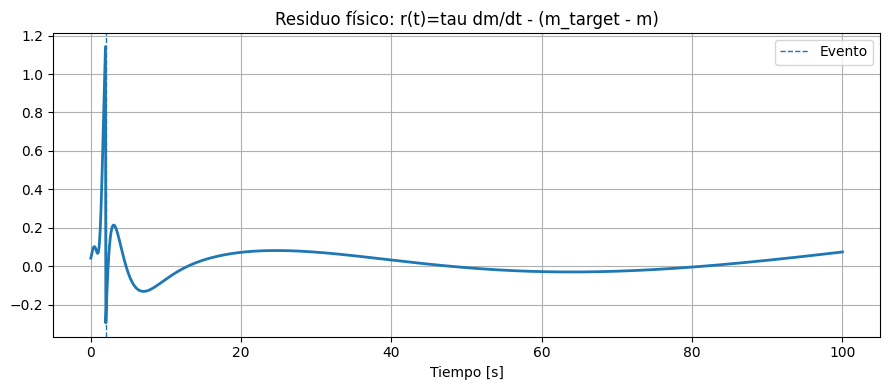

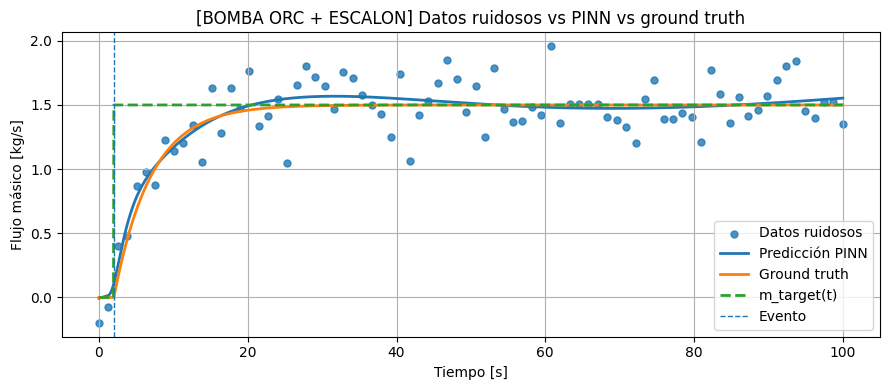

[LOSS final train]: [1.7856199e-02 5.6326546e-04 1.5785254e+00]
Backend DeepXDE: tensorflow


In [3]:
# ============================================================
# [BLOQUE 2] PINN (DeepXDE) — BOMBA ORC
# Salida de la red: m(t)
#
# EDO:
#   tau_pump * dm/dt = m_target(t) - m(t)
#
# Entrenamiento:
#   Física + condición inicial + datos ruidosos
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
import tensorflow as tf

# -----------------------------
# Configuración general
# -----------------------------
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

CASO = "ESCALON"       # "ESCALON" o "COSENO"
t_evento = 2.0

n_datos = 80
sigma_ruido_m = 0.2

num_fisica = 400
num_boundary = 20

# Pesos: [PDE, IC, DATA]
loss_weights = [0.6, 20.0, 50.0]

USAR_ANCHORS = True
ANCHOR_WINDOW = 2.0
N_ANCHORS = 100

# -----------------------------
# Cargar ground truth del bloque 1
# -----------------------------
d = df_todos_bomba[df_todos_bomba["caso"] == CASO].sort_values("t")
if d.empty:
    raise ValueError(f"No existe el caso {CASO}")

t_eval = d["t"].to_numpy()
m_true = d["m"].to_numpy()
m_target_eval = d["m_target"].to_numpy()
tau_pump = float(d["tau_pump"].iloc[0])

t_inicio = float(t_eval.min())
t_final = float(t_eval.max())
m0 = float(m_true[0])

print(f"[INFO] Caso={CASO}, tau_pump={tau_pump}, m0={m0}")

# -----------------------------
# Construir observaciones ruidosas
# -----------------------------
idx = np.linspace(0, len(t_eval) - 1, n_datos).astype(int)
t_datos = t_eval[idx]
m_datos_true = m_true[idx]

rng = np.random.default_rng(SEED)
m_ruidoso = m_datos_true + rng.normal(0.0, sigma_ruido_m, size=m_datos_true.shape)

t_datos_dd = t_datos.reshape(-1, 1)
m_ruidoso_dd = m_ruidoso.reshape(-1, 1)

# -----------------------------
# Definir m_target(t) en TensorFlow
# -----------------------------
def mtarget_tf(t):
    if CASO.upper() == "ESCALON":
        t0 = tf.constant(2.0, dtype=t.dtype)
        A = tf.constant(1.5, dtype=t.dtype)
        return tf.where(t >= t0, A * tf.ones_like(t), tf.zeros_like(t))

    elif CASO.upper() == "COSENO":
        t0 = tf.constant(2.0, dtype=t.dtype)
        A = tf.constant(0.2, dtype=t.dtype)
        bias = tf.constant(1.2, dtype=t.dtype)
        w = tf.constant(0.4, dtype=t.dtype)
        return tf.where(t < t0, bias * tf.ones_like(t), bias + A * tf.cos(w * (t - t0)))

    elif CASO.upper() == "RAMPA":
        t0 = tf.constant(2.0, dtype=t.dtype)
        dur = tf.constant(8.0, dtype=t.dtype)
        m_ini = tf.constant(0.0, dtype=t.dtype)
        m_fin = tf.constant(1.5, dtype=t.dtype)
        pendiente = (m_fin - m_ini) / dur

        return tf.where(
            t < t0,
            m_ini * tf.ones_like(t),
            tf.where(
                t < t0 + dur,
                m_ini + pendiente * (t - t0),
                m_fin * tf.ones_like(t)
            )
        )

    elif CASO.upper() == "PULSO":
        t1 = tf.constant(5.0, dtype=t.dtype)
        t2 = tf.constant(20.0, dtype=t.dtype)
        m_base = tf.constant(0.0, dtype=t.dtype)
        m_alto = tf.constant(1.5, dtype=t.dtype)

        return tf.where(
            tf.logical_and(t >= t1, t < t2),
            m_alto * tf.ones_like(t),
            m_base * tf.ones_like(t)
        )

    else:
        return tf.zeros_like(t)

# -----------------------------
# Definir geometría y PDE
# -----------------------------
geom = dde.geometry.TimeDomain(t_inicio, t_final)

def pde_bomba(t, m):
    m_t = dde.grad.jacobian(m, t, i=0, j=0)
    return tau_pump * m_t - (mtarget_tf(t) - m)

def on_initial(t, is_initial):
    return is_initial

# IC: m(0)=m0
ic_m = dde.icbc.IC(geom, lambda t: m0, on_initial)

# Observaciones ruidosas
obs_m = dde.icbc.PointSetBC(t_datos_dd, m_ruidoso_dd, component=0)

# Anchors cerca del escalón
anchors = None
if USAR_ANCHORS:
    t_left = max(t_inicio, t_evento - ANCHOR_WINDOW)
    t_right = min(t_final, t_evento + ANCHOR_WINDOW)
    anchors = np.linspace(t_left, t_right, N_ANCHORS).reshape(-1, 1)

data = dde.data.TimePDE(
    geom,
    pde_bomba,
    [ic_m, obs_m],
    num_domain=num_fisica,
    num_boundary=num_boundary,
    anchors=anchors
)

# -----------------------------
# Red neuronal
# -----------------------------
net = dde.nn.FNN([1, 64, 64, 64, 1], "tanh", "Glorot normal")
model = dde.Model(data, net)

# -----------------------------
# Entrenamiento
# -----------------------------
model.compile("adam", lr=5e-4, loss_weights=loss_weights)
losshistory, train_state = model.train(iterations=8000, display_every=200)

model.compile("L-BFGS", loss_weights=loss_weights)
losshistory, train_state = model.train()

# -----------------------------
# Evaluación
# -----------------------------
t_eval_dd = t_eval.reshape(-1, 1)
m_pinn = model.predict(t_eval_dd).reshape(-1)

# Métricas
mse = np.mean((m_pinn - m_true) ** 2)
mae = np.mean(np.abs(m_pinn - m_true))
r2 = 1.0 - (np.sum((m_true - m_pinn) ** 2) / np.sum((m_true - np.mean(m_true)) ** 2))

print(f"[MÉTRICAS] MAE={mae:.4e} | MSE={mse:.4e} | R2={r2:.6f}")

# Residuo físico
r = model.predict(t_eval_dd, operator=pde_bomba).reshape(-1)

plt.figure(figsize=(9, 4))
plt.plot(t_eval, r, lw=2)
plt.axvline(t_evento, ls="--", lw=1, label="Evento")
plt.title("Residuo físico: r(t)=tau dm/dt - (m_target - m)")
plt.xlabel("Tiempo [s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Comparación visual
plt.figure(figsize=(9, 4))
plt.scatter(t_datos, m_ruidoso, s=25, alpha=0.8, label="Datos ruidosos")
plt.plot(t_eval, m_pinn, lw=2, label="Predicción PINN")
plt.plot(t_eval, m_true, lw=2, label="Ground truth")
plt.plot(t_eval, m_target_eval, "--", lw=2, label="m_target(t)")
plt.axvline(t_evento, ls="--", lw=1, label="Evento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo másico [kg/s]")
plt.title(f"[BOMBA ORC + {CASO}] Datos ruidosos vs PINN vs ground truth")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("[LOSS final train]:", losshistory.loss_train[-1])

try:
    print("Backend DeepXDE:", dde.backend.backend_name())
except Exception:
    print("Backend DeepXDE:", getattr(dde.backend, "backend_name", "desconocido"))

# Bloque extra. Visualizaciones y análisis de resultados de la PINN

En este bloque se presentan un conjunto de gráficas y métricas complementarias para interpretar el desempeño de la PINN aplicada a la dinámica de la bomba ORC. Mientras que en los bloques anteriores se construyó el modelo y se realizó el entrenamiento, aquí el objetivo es analizar visualmente qué tan bien la red reconstruye la solución del sistema y qué tan consistente es con la física del problema.

Primero se muestra la relación entre la señal de entrada $m_{target}(t)$ y la respuesta verdadera $m_{true}(t)$, lo cual permite entender la dinámica que se desea aprender. Luego se incluye un diagrama general del proceso seguido en el experimento, desde la ecuación diferencial hasta la predicción final de la PINN, con el fin de resumir de forma didáctica la metodología implementada.

Posteriormente, se compara la predicción de la PINN con los datos observados con ruido y con la solución verdadera. Esta figura es una de las más importantes del análisis, ya que permite verificar si la red logra reconstruir correctamente la trayectoria del flujo másico a partir de observaciones limitadas y perturbadas.

También se calcula y grafica el residuo físico,

$$
r(t) = \tau_{pump}\frac{d\hat{m}(t)}{dt} - \left(m_{target}(t) - \hat{m}(t)\right)
$$

el cual permite evaluar qué tan bien la solución aprendida satisface la ecuación diferencial. De manera complementaria, se representa el error absoluto en el tiempo para identificar en qué regiones del dominio la PINN presenta mayores desviaciones.

Además, se muestra la evolución de la pérdida durante el entrenamiento, lo cual permite observar la convergencia del modelo. Finalmente, se compara la PINN con un ajuste spline construido únicamente a partir de los datos observados. Esta comparación permite evidenciar la ventaja de incorporar información física en el proceso de aprendizaje, ya que la PINN tiende a producir soluciones más suaves, robustas e interpretables.

En conjunto, este bloque permite complementar el análisis numérico con una interpretación visual del comportamiento del modelo, mostrando tanto la calidad del ajuste como el grado de cumplimiento de la física del sistema.

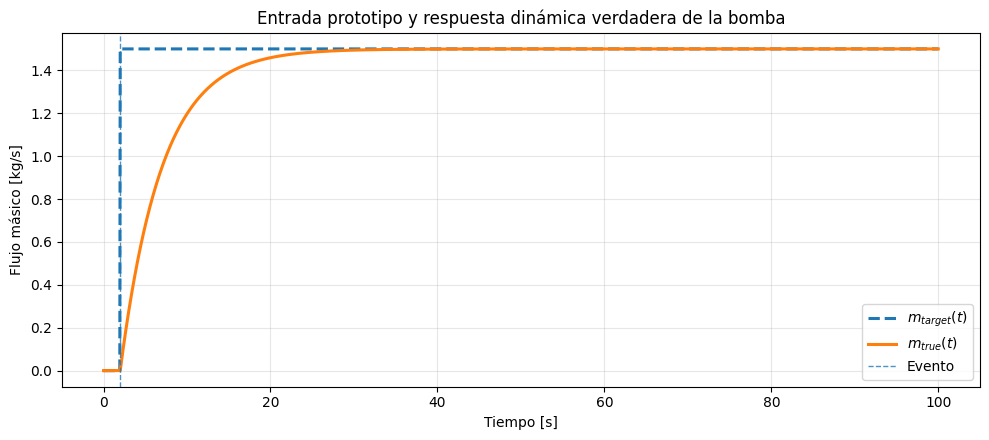

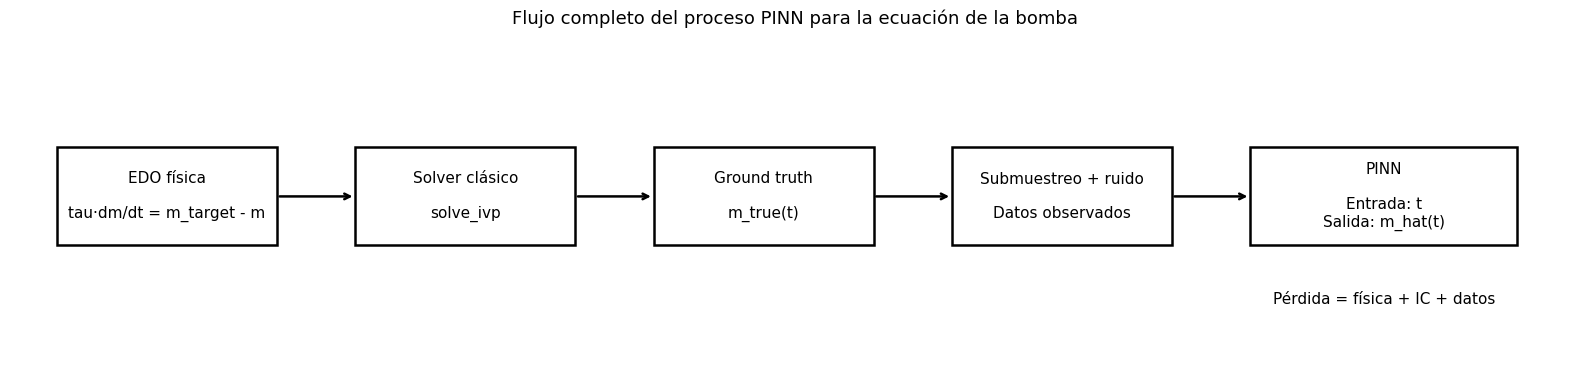

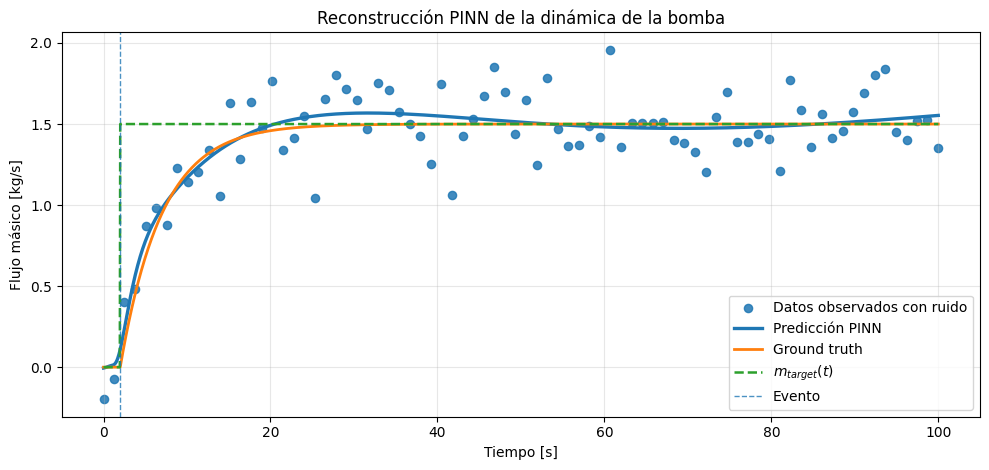

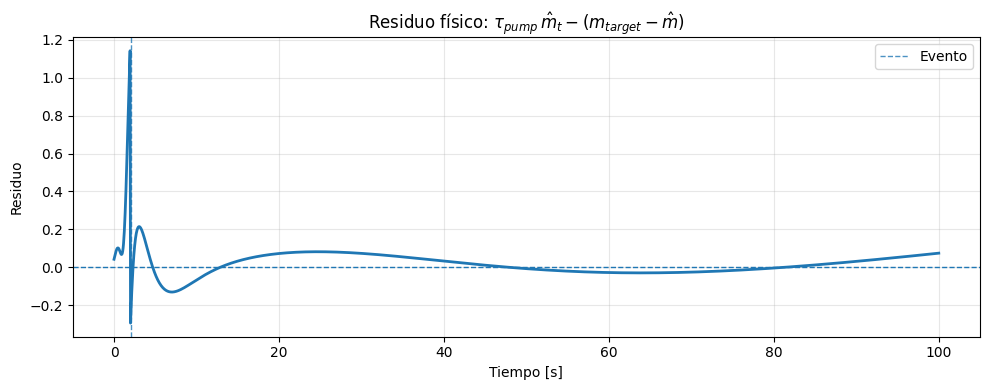

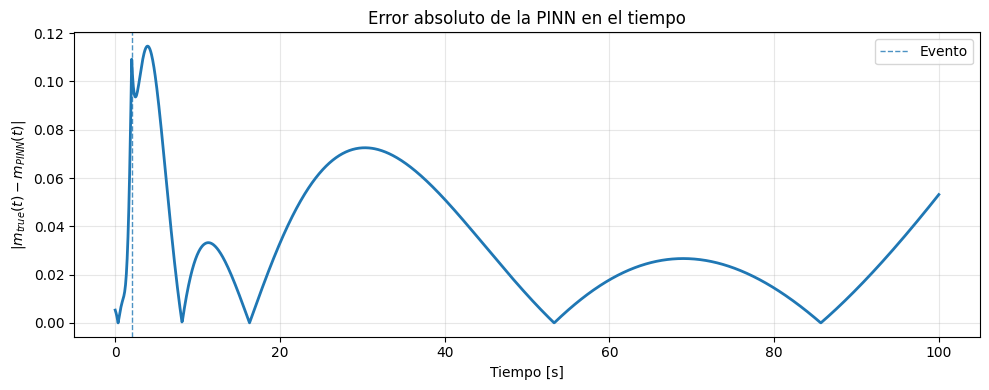

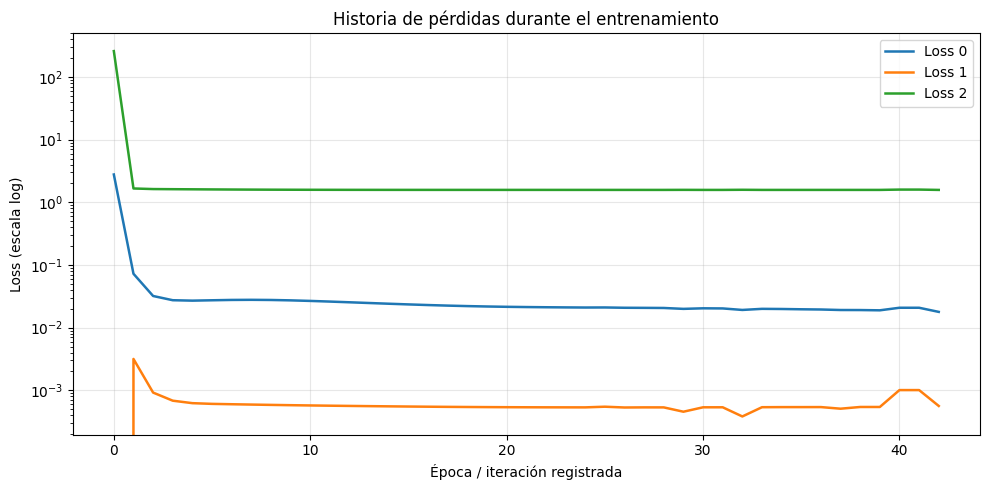

PINN         | MAE=3.2524e-02 | RMSE=4.0872e-02 | R2=0.981576
Spline       | MAE=1.2532e-01 | RMSE=1.5712e-01 | R2=0.727726


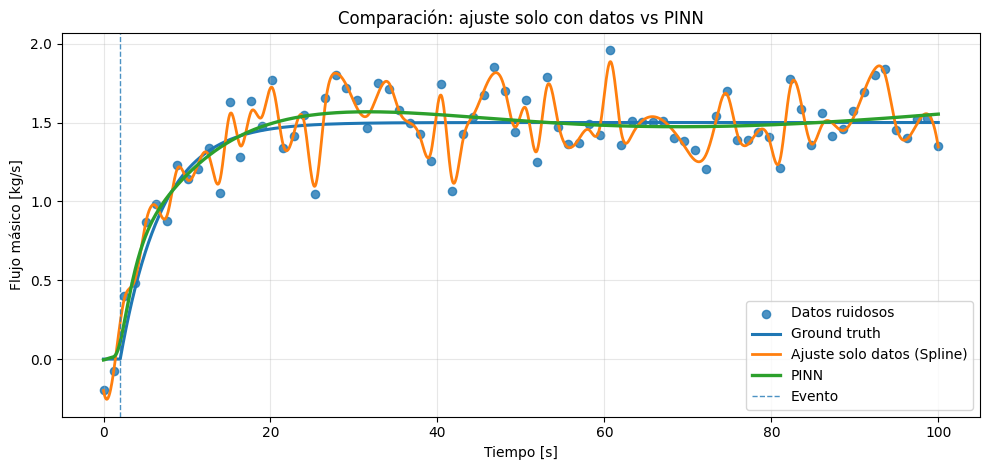


================ RESUMEN DE MÉTRICAS ================
PINN   -> MAE=3.2524e-02 | RMSE=4.0872e-02 | R2=0.981576
Spline -> MAE=1.2532e-01 | RMSE=1.5712e-01 | R2=0.727726
Residuo físico PINN -> mean(|r|)=4.6414e-02 | max(|r|)=1.1425e+00


In [5]:
# ============================================================
# [BLOQUE EXTRA] VISUALIZACIONES Y ANÁLISIS DIDÁCTICO — PINN BOMBA
# Requiere haber ejecutado previamente:
# - generación de datos
# - entrenamiento PINN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# ------------------------------------------------------------
# [1] FIGURA: Entrada prototipo y respuesta verdadera
# ------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
plt.plot(t_eval, m_target_eval, "--", linewidth=2.2, label=r"$m_{target}(t)$")
plt.plot(t_eval, m_true, linewidth=2.2, label=r"$m_{true}(t)$")
plt.axvline(t_evento, linestyle="--", linewidth=1, alpha=0.8, label="Evento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo másico [kg/s]")
plt.title("Entrada prototipo y respuesta dinámica verdadera de la bomba")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [2] FIGURA: Pipeline completo del proceso
# (diagrama simple hecho con matplotlib)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 3.8))
ax.axis("off")

# Posiciones de cajas
boxes = [
    (0.03, 0.35, 0.14, 0.30, "EDO física\n\ntau·dm/dt = m_target - m"),
    (0.22, 0.35, 0.14, 0.30, "Solver clásico\n\nsolve_ivp"),
    (0.41, 0.35, 0.14, 0.30, "Ground truth\n\nm_true(t)"),
    (0.60, 0.35, 0.14, 0.30, "Submuestreo + ruido\n\nDatos observados"),
    (0.79, 0.35, 0.17, 0.30, "PINN\n\nEntrada: t\nSalida: m_hat(t)")
]

for (x, y, w, h, txt) in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.8)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=11)

# Flechas
arrow_y = 0.50
for x1, x2 in [(0.17, 0.22), (0.36, 0.41), (0.55, 0.60), (0.74, 0.79)]:
    ax.annotate(
        "", xy=(x2, arrow_y), xytext=(x1, arrow_y),
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

# Texto extra
ax.text(0.875, 0.17, "Pérdida = física + IC + datos", ha="center", fontsize=11)
ax.set_title("Flujo completo del proceso PINN para la ecuación de la bomba", fontsize=13)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [3] FIGURA: Predicción PINN vs datos ruidosos vs ground truth
# ------------------------------------------------------------
plt.figure(figsize=(10, 4.8))
plt.scatter(t_datos, m_ruidoso, s=35, alpha=0.85, label="Datos observados con ruido")
plt.plot(t_eval, m_pinn, linewidth=2.4, label="Predicción PINN")
plt.plot(t_eval, m_true, linewidth=2.0, label="Ground truth")
plt.plot(t_eval, m_target_eval, "--", linewidth=1.8, label=r"$m_{target}(t)$")
plt.axvline(t_evento, linestyle="--", linewidth=1, alpha=0.8, label="Evento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo másico [kg/s]")
plt.title("Reconstrucción PINN de la dinámica de la bomba")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [4] FIGURA: Residuo físico
# ------------------------------------------------------------
t_eval_dd = t_eval.reshape(-1, 1)
r = model.predict(t_eval_dd, operator=pde_bomba).reshape(-1)

plt.figure(figsize=(10, 4))
plt.plot(t_eval, r, linewidth=2)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(t_evento, linestyle="--", linewidth=1, alpha=0.8, label="Evento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Residuo")
plt.title(r"Residuo físico: $\tau_{pump}\,\hat m_t - (m_{target} - \hat m)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [5] FIGURA: Error absoluto en el tiempo
# ------------------------------------------------------------
error_abs = np.abs(m_true - m_pinn)

plt.figure(figsize=(10, 4))
plt.plot(t_eval, error_abs, linewidth=2)
plt.axvline(t_evento, linestyle="--", linewidth=1, alpha=0.8, label="Evento")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$|m_{true}(t) - m_{PINN}(t)|$")
plt.title("Error absoluto de la PINN en el tiempo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [6] FIGURA: Curvas de pérdida del entrenamiento
# ------------------------------------------------------------
loss_train = np.array(losshistory.loss_train)

plt.figure(figsize=(10, 5))

if loss_train.ndim == 2:
    # columna 0: total o primer término según backend/historial
    for j in range(loss_train.shape[1]):
        plt.semilogy(loss_train[:, j], linewidth=1.8, label=f"Loss {j}")
else:
    plt.semilogy(loss_train, linewidth=2, label="Loss train")

plt.xlabel("Época / iteración registrada")
plt.ylabel("Loss (escala log)")
plt.title("Historia de pérdidas durante el entrenamiento")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [7] Comparación contra un ajuste solo con datos (Spline)
# ------------------------------------------------------------
# Ajuste suave usando solo los datos observados
# s controla el suavizado; puedes moverlo si quieres más/menos suavidad
orden = np.argsort(t_datos)
t_datos_sorted = t_datos[orden]
m_ruidoso_sorted = m_ruidoso[orden]

spline = UnivariateSpline(t_datos_sorted, m_ruidoso_sorted, s=len(t_datos_sorted) * 0.002)
m_spline = spline(t_eval)

# Métricas comparativas
def metricas(y_true, y_pred, nombre="modelo"):
    mse = np.mean((y_pred - y_true) ** 2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(mse)
    r2 = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    print(f"{nombre:12s} | MAE={mae:.4e} | RMSE={rmse:.4e} | R2={r2:.6f}")

metricas(m_true, m_pinn, "PINN")
metricas(m_true, m_spline, "Spline")

plt.figure(figsize=(10, 4.8))
plt.scatter(t_datos, m_ruidoso, s=35, alpha=0.8, label="Datos ruidosos")
plt.plot(t_eval, m_true, linewidth=2.2, label="Ground truth")
plt.plot(t_eval, m_spline, linewidth=2.0, label="Ajuste solo datos (Spline)")
plt.plot(t_eval, m_pinn, linewidth=2.4, label="PINN")
plt.axvline(t_evento, linestyle="--", linewidth=1, alpha=0.8, label="Evento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo másico [kg/s]")
plt.title("Comparación: ajuste solo con datos vs PINN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# [8] Tabla resumen de métricas
# ------------------------------------------------------------
mse_pinn = np.mean((m_pinn - m_true) ** 2)
mae_pinn = np.mean(np.abs(m_pinn - m_true))
rmse_pinn = np.sqrt(mse_pinn)
r2_pinn = 1.0 - np.sum((m_true - m_pinn) ** 2) / np.sum((m_true - np.mean(m_true)) ** 2)

mse_spline = np.mean((m_spline - m_true) ** 2)
mae_spline = np.mean(np.abs(m_spline - m_true))
rmse_spline = np.sqrt(mse_spline)
r2_spline = 1.0 - np.sum((m_true - m_spline) ** 2) / np.sum((m_true - np.mean(m_true)) ** 2)

residuo_abs_mean = np.mean(np.abs(r))
residuo_abs_max = np.max(np.abs(r))

print("\n================ RESUMEN DE MÉTRICAS ================")
print(f"PINN   -> MAE={mae_pinn:.4e} | RMSE={rmse_pinn:.4e} | R2={r2_pinn:.6f}")
print(f"Spline -> MAE={mae_spline:.4e} | RMSE={rmse_spline:.4e} | R2={r2_spline:.6f}")
print(f"Residuo físico PINN -> mean(|r|)={residuo_abs_mean:.4e} | max(|r|)={residuo_abs_max:.4e}")